In [1]:
from pathlib import Path
import glob, os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font='SimHei')

DATA_DIR = Path(r'C:\Users\fire\all2')
OUTPUT_DIR = Path('chapter8_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
print('输出目录：', OUTPUT_DIR.resolve())

输出目录： C:\Users\fire\xhs\chapter8_outputs


In [2]:
all_files = glob.glob(str(DATA_DIR / '*.csv'))
detail_files = [f for f in all_files if '笔记详细信息' in os.path.basename(f)]

frames = []
for f in detail_files:
    try:
        frames.append(pd.read_csv(f, encoding='utf-8-sig', low_memory=False))
    except Exception as e:
        print('跳过：', os.path.basename(f), e)

df = pd.concat(frames, ignore_index=True)
before = len(df)

# 优先按唯一链接去重；无链接记录用编号、标题、作者联合去重
link = df['具体链接'].astype('string').str.strip()
has_link = link.notna() & link.ne('') & link.ne('nan')
with_link = df.loc[has_link].drop_duplicates('具体链接')
without_link = df.loc[~has_link].drop_duplicates(['编号', '文案（标题）', '博主名称'])
df = pd.concat([with_link, without_link], ignore_index=True)

print(f'读取详情文件：{len(detail_files)} 个')
print(f'去重前：{before:,} 行；去重后：{len(df):,} 行；移除：{before-len(df):,} 行')

读取详情文件：52 个
去重前：207,373 行；去重后：185,217 行；移除：22,156 行


In [3]:
def numeric(col):
    return pd.to_numeric(df[col], errors='coerce')

df['likes'] = numeric('相对准确点赞数')
df['comments'] = numeric('相对准确评论数')
df['favs'] = numeric('相对准确收藏数')
df['fans'] = numeric('相对准确粉丝数')
df = df.dropna(subset=['likes', 'comments', 'favs']).copy()
df[['likes', 'comments', 'favs']] = df[['likes', 'comments', 'favs']].clip(lower=0)

df['engagement'] = df['likes'] + df['favs'] + 4 * df['comments']
df['engagement_log'] = np.log1p(df['engagement'])
df['log_fans'] = np.log1p(df['fans'].clip(lower=0))

title = df['文案（标题）'].fillna('').astype(str)
body = df['文案（正文）'].fillna('').astype(str)
text = (title + ' ' + body).str.strip()
df['title_len'] = title.str.len()
df['body_len'] = body.str.len()
df['content_len'] = text.str.len()
df['tag_count'] = df['标签词'].fillna('').astype(str).apply(lambda s: 0 if not s.strip() else len([x for x in s.split(',') if x.strip()]))
df['exclamation_count'] = text.str.count(r'[!！]')
df['question_count'] = text.str.count(r'[?？]')
df['emoji_count'] = text.apply(lambda s: len(re.findall(r'[\U0001F300-\U0001FAFF]', s)))
df['emotion_positive'] = pd.to_numeric(df['情感预测'], errors='coerce').clip(0, 1)
df['emotion_extremity'] = (df['emotion_positive'] - 0.5).abs()

post_date = pd.to_datetime(df['推断笔记发布日期'], errors='coerce')
df['weekday'] = post_date.dt.dayofweek
location = df['笔记发布地'].fillna('').astype(str).str.strip()
df['has_location'] = (~location.isin(['', 'nan', '-9999'])).astype(int)
df['category'] = np.where(df['具体链接'].notna(), '笔记', '未知')  # 文件合并后无可靠来源列，不用于类别推断

# 标题-正文词汇重合度（简单且可解释，不等同于语义相似度）
token_pattern = re.compile(r'[\u4e00-\u9fffA-Za-z0-9]+')
def title_body_overlap(t, b):
    a = set(token_pattern.findall(t.lower()))
    c = set(token_pattern.findall(b.lower()))
    return len(a & c) / len(a) if a else 0.0
df['title_body_overlap'] = [title_body_overlap(t, b) for t, b in zip(title, body)]

viral_cutoff = df['engagement'].quantile(0.90)
df['is_viral'] = (df['engagement'] >= viral_cutoff).astype(int)
print(f'最终样本：{len(df):,}；爆款阈值：互动量 ≥ {viral_cutoff:.1f}；爆款比例：{df.is_viral.mean():.2%}')

最终样本：182,103；爆款阈值：互动量 ≥ 6283.0；爆款比例：10.00%


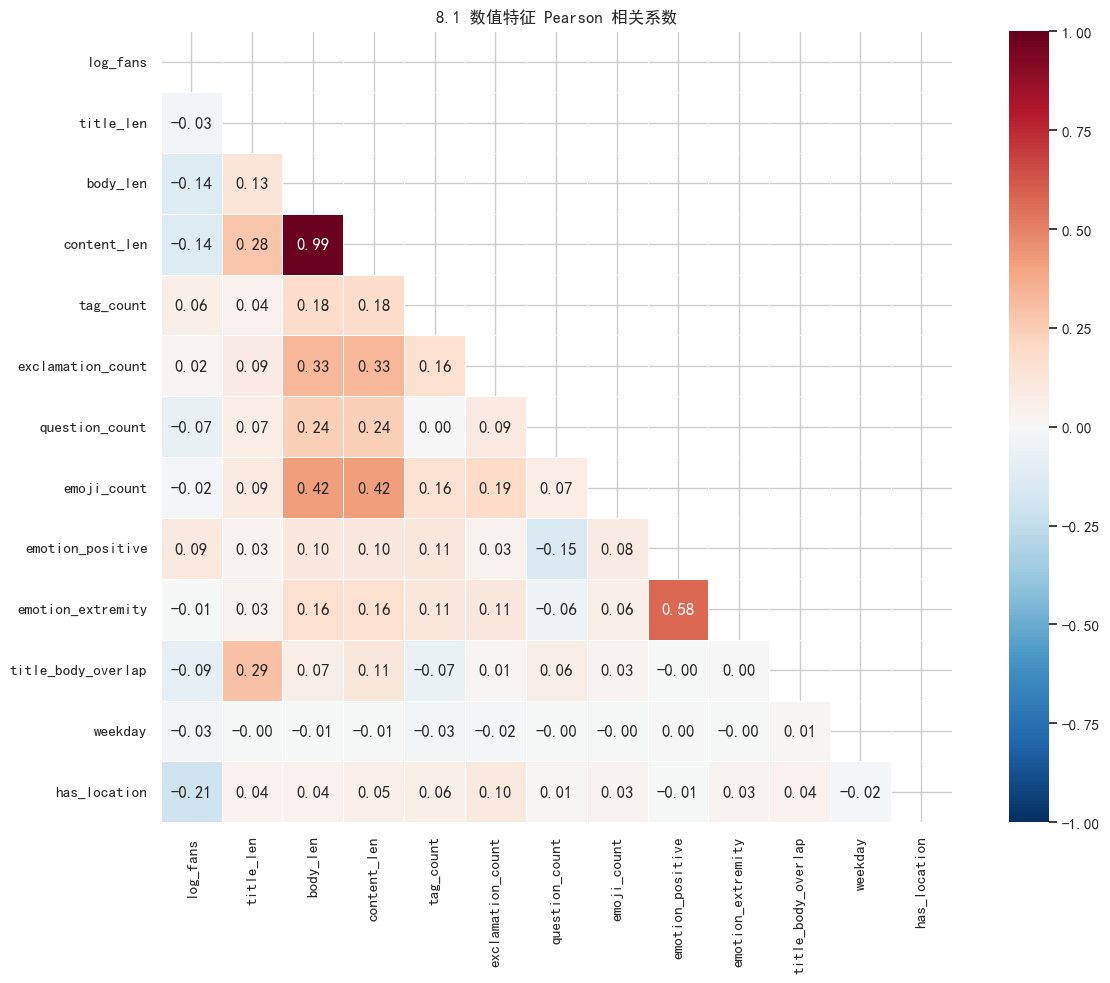

,feature_1,feature_2,pearson_r
0,body_len,content_len,0.987672


In [4]:
features = [
    'log_fans', 'title_len', 'body_len', 'content_len', 'tag_count',
    'exclamation_count', 'question_count', 'emoji_count',
    'emotion_positive', 'emotion_extremity', 'title_body_overlap',
    'weekday', 'has_location'
]

pearson = df[features].corr(method='pearson')
spearman = df[features].corr(method='spearman')
pearson.to_csv(OUTPUT_DIR / '8_1_pearson_features.csv', encoding='utf-8-sig')
spearman.to_csv(OUTPUT_DIR / '8_1_spearman_features.csv', encoding='utf-8-sig')

mask = np.triu(np.ones_like(pearson, dtype=bool))
plt.figure(figsize=(13, 10))
sns.heatmap(pearson, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', square=True, linewidths=.4)
plt.title('8.1 数值特征 Pearson 相关系数')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '8_1_pearson_heatmap.png', dpi=180)
plt.show()

pairs = []
for i, a in enumerate(features):
    for b in features[i+1:]:
        r = pearson.loc[a, b]
        if pd.notna(r) and abs(r) >= 0.8:
            pairs.append((a, b, r))
high_corr = pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'pearson_r']).sort_values('pearson_r', key=abs, ascending=False) if pairs else pd.DataFrame(columns=['feature_1','feature_2','pearson_r'])
high_corr.to_csv(OUTPUT_DIR / '8_1_high_correlation_pairs.csv', index=False, encoding='utf-8-sig')
display(high_corr if len(high_corr) else pd.DataFrame({'结论':['未发现 |r| ≥ 0.8 的特征对']}))

,feature,n,pearson_r,pearson_p,spearman_rho,spearman_p,pearson_p_fdr,spearman_p_fdr
0,log_fans,168323,0.48874,0.0,0.46874,0.0,0.0,0.0
2,body_len,182103,-0.13374,0.0,-0.11553,0.0,0.0,0.0
3,content_len,182103,-0.13590,0.0,-0.11518,0.0,0.0,0.0
12,has_location,182103,-0.12254,0.0,-0.11145,0.0,0.0,0.0
9,emotion_extremity,182103,-0.07253,0.0,-0.07048,0.0,0.0,0.0
10,title_body_overlap,182103,-0.07337,0.0,-0.06762,0.0,0.0,0.0
8,emotion_positive,182103,-0.05358,0.0,-0.06307,0.0,0.0,0.0
4,tag_count,182103,-0.05715,0.0,-0.04358,0.0,0.0,0.0
7,emoji_count,182103,-0.06943,0.0,-0.02616,0.0,0.0,0.0
11,weekday,181746,-0.02777,0.0,-0.02413,0.0,0.0,0.0


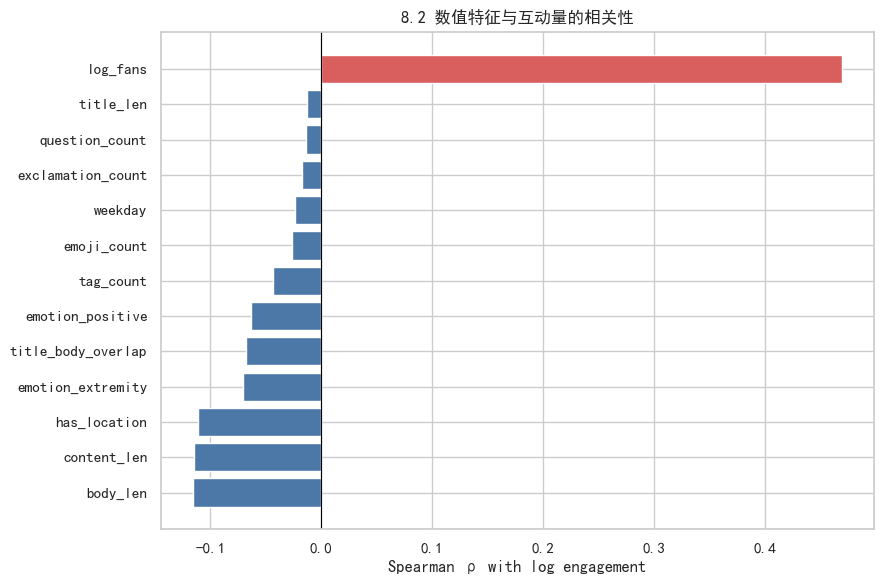

In [5]:
rows = []
for x in features:
    z = df[[x, 'engagement_log']].dropna()
    pr, pp = stats.pearsonr(z[x], z['engagement_log']) if z[x].nunique() > 1 else (np.nan, np.nan)
    sr, sp = stats.spearmanr(z[x], z['engagement_log']) if z[x].nunique() > 1 else (np.nan, np.nan)
    rows.append([x, len(z), pr, pp, sr, sp])

target_corr = pd.DataFrame(rows, columns=['feature','n','pearson_r','pearson_p','spearman_rho','spearman_p'])
target_corr['pearson_p_fdr'] = multipletests(target_corr['pearson_p'].fillna(1), method='fdr_bh')[1]
target_corr['spearman_p_fdr'] = multipletests(target_corr['spearman_p'].fillna(1), method='fdr_bh')[1]
target_corr = target_corr.sort_values('spearman_rho', key=abs, ascending=False)
target_corr.to_csv(OUTPUT_DIR / '8_2_numeric_target_correlations.csv', index=False, encoding='utf-8-sig')
display(target_corr.round(5))

plt.figure(figsize=(9, 6))
plot_corr = target_corr.sort_values('spearman_rho')
plt.barh(plot_corr['feature'], plot_corr['spearman_rho'], color=np.where(plot_corr['spearman_rho'] >= 0, '#D95F5F', '#4C78A8'))
plt.axvline(0, color='black', lw=.8)
plt.xlabel('Spearman ρ with log engagement')
plt.title('8.2 数值特征与互动量的相关性')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '8_2_target_correlation_ranking.png', dpi=180)
plt.show()

In [6]:
def cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    pooled = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean()-b.mean()) / pooled if pooled > 0 else np.nan

rows = []
for x in features:
    z = df[[x, 'is_viral']].dropna()
    viral = z.loc[z.is_viral == 1, x]
    normal = z.loc[z.is_viral == 0, x]
    if z[x].nunique() <= 1:
        continue
    r_pb, p_pb = stats.pointbiserialr(z['is_viral'], z[x])
    t, p_t = stats.ttest_ind(viral, normal, equal_var=False)
    u, p_u = stats.mannwhitneyu(viral, normal, alternative='two-sided')
    rows.append([x, len(z), normal.mean(), viral.mean(), r_pb, p_pb, t, p_t, u, p_u, cohens_d(viral, normal)])

viral_tests = pd.DataFrame(rows, columns=[
    'feature','n','nonviral_mean','viral_mean','point_biserial_r','point_biserial_p',
    'welch_t','welch_p','mannwhitney_u','mannwhitney_p','cohens_d_viral_minus_nonviral'
])
for c in ['point_biserial_p','welch_p','mannwhitney_p']:
    viral_tests[c + '_fdr'] = multipletests(viral_tests[c].fillna(1), method='fdr_bh')[1]
viral_tests = viral_tests.sort_values('cohens_d_viral_minus_nonviral', key=abs, ascending=False)
viral_tests.to_csv(OUTPUT_DIR / '8_2_viral_group_tests.csv', index=False, encoding='utf-8-sig')
display(viral_tests.round(5))

,feature,n,nonviral_mean,viral_mean,point_biserial_r,point_biserial_p,welch_t,welch_p,mannwhitney_u,mannwhitney_p,cohens_d_viral_minus_nonviral,point_biserial_p_fdr,welch_p_fdr,mannwhitney_p_fdr
0,log_fans,168323,7.61275,9.58872,0.20580,0.00000,89.32066,0.00000,1.787451e+09,0.00000,0.69565,0.00000,0.00000,0.00000
2,body_len,182103,96.49376,59.61714,-0.06375,0.00000,-35.20417,0.00000,1.332326e+09,0.00000,-0.21292,0.00000,0.00000,0.00000
3,content_len,182103,114.84036,76.96283,-0.06323,0.00000,-34.78241,0.00000,1.333976e+09,0.00000,-0.21118,0.00000,0.00000,0.00000
4,tag_count,182103,6.51713,5.74425,-0.04101,0.00000,-19.82505,0.00000,1.374957e+09,0.00000,-0.13681,0.00000,0.00000,0.00000
9,emotion_extremity,182103,0.36727,0.35024,-0.03584,0.00000,-14.78209,0.00000,1.390356e+09,0.00000,-0.11954,0.00000,0.00000,0.00000
7,emoji_count,182103,1.07427,0.75600,-0.03548,0.00000,-18.72266,0.00000,1.413316e+09,0.00000,-0.11834,0.00000,0.00000,0.00000
8,emotion_positive,182103,0.78685,0.76461,-0.02471,0.00000,-10.44157,0.00000,1.404571e+09,0.00000,-0.08239,0.00000,0.00000,0.00000
5,exclamation_count,182103,1.24067,1.09142,-0.01590,0.00000,-7.85447,0.00000,1.483906e+09,0.14460,-0.05300,0.00000,0.00000,0.17089
10,title_body_overlap,182103,0.04020,0.03267,-0.01349,0.00000,-6.23540,0.00000,1.474817e+09,0.00000,-0.04496,0.00000,0.00000,0.00000
1,title_len,182103,17.99670,17.08543,-0.00965,0.00004,-5.13979,0.00000,1.455850e+09,0.00000,-0.03217,0.00005,0.00000,0.00000


,样本量,平均log互动,中位log互动,爆款比例
周一,24582,6.0833,6.0822,0.1042
周二,25298,5.9729,5.9283,0.1023
周三,27339,5.9230,5.8493,0.1009
周四,29280,5.7048,5.6664,0.0949
周五,31151,5.2200,5.2983,0.0854
周六,23158,6.0707,6.0355,0.1091
周日,20938,6.0667,6.0521,0.1086


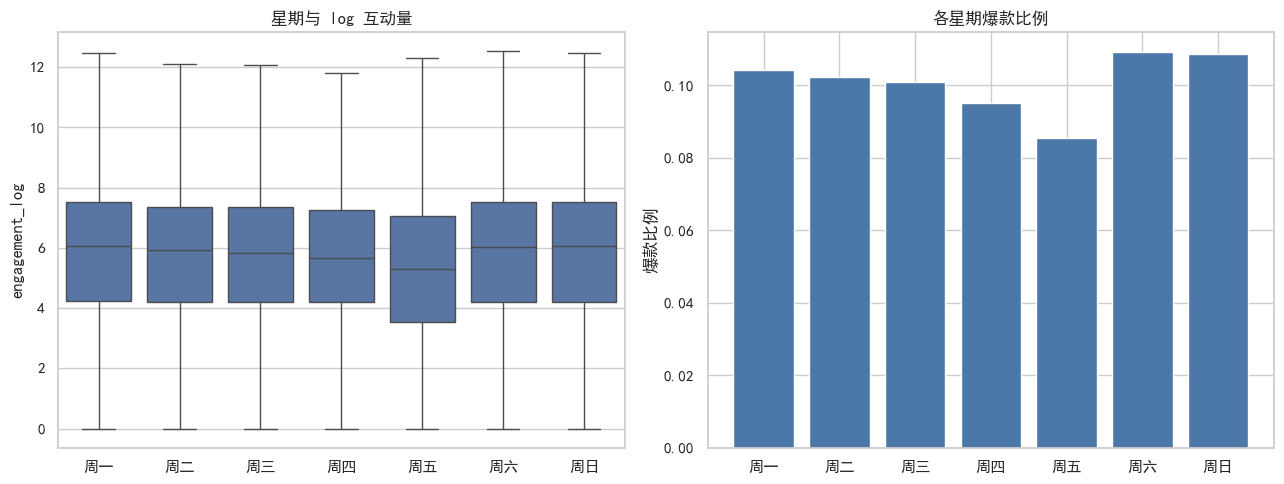

In [7]:
weekday_names = ['周一','周二','周三','周四','周五','周六','周日']
weekday_summary = df.dropna(subset=['weekday']).groupby('weekday').agg(
    样本量=('engagement_log','size'),
    平均log互动=('engagement_log','mean'),
    中位log互动=('engagement_log','median'),
    爆款比例=('is_viral','mean')
).reindex(range(7))
weekday_summary.index = weekday_names
weekday_summary.to_csv(OUTPUT_DIR / '8_2_weekday_summary.csv', encoding='utf-8-sig')
display(weekday_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df.dropna(subset=['weekday']), x='weekday', y='engagement_log', showfliers=False, ax=axes[0])
axes[0].set_xticklabels(weekday_names)
axes[0].set_title('星期与 log 互动量')
axes[0].set_xlabel('')
axes[1].bar(weekday_names, weekday_summary['爆款比例'], color='#4C78A8')
axes[1].set_title('各星期爆款比例')
axes[1].set_ylabel('爆款比例')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '8_2_weekday_comparison.png', dpi=180)
plt.show()

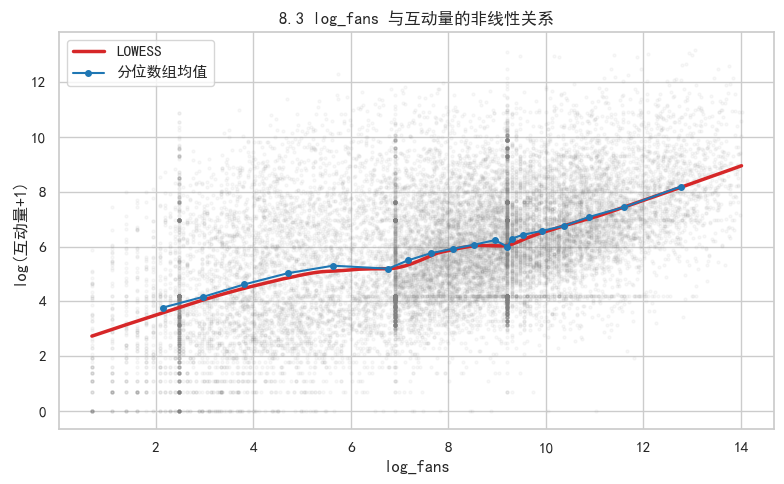

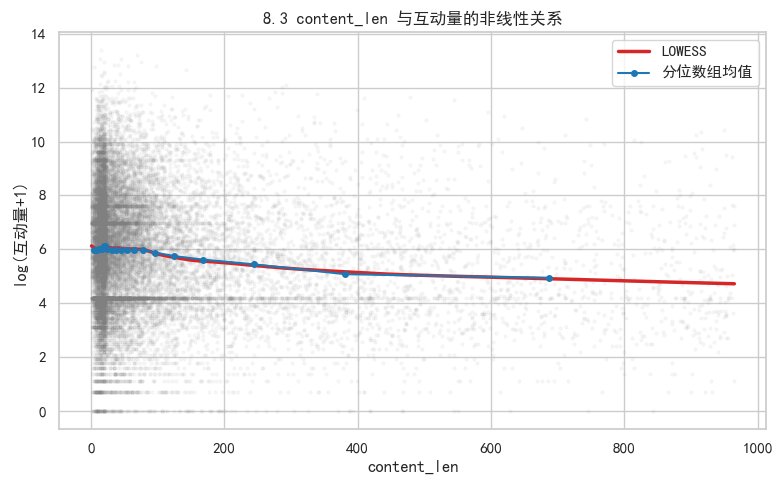

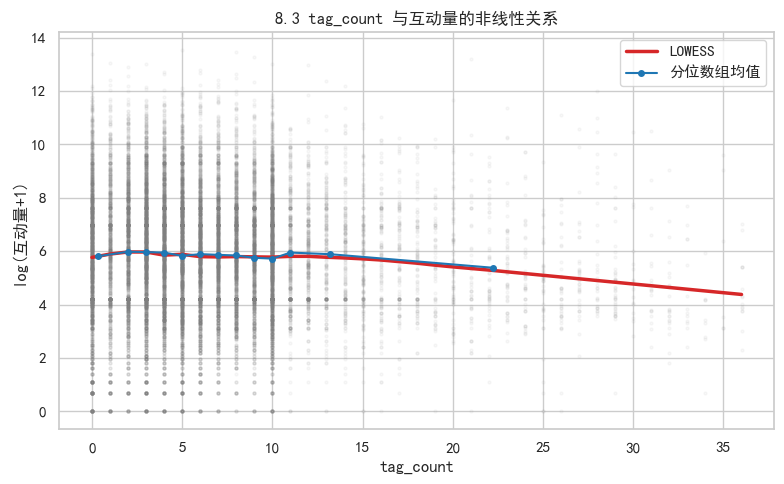

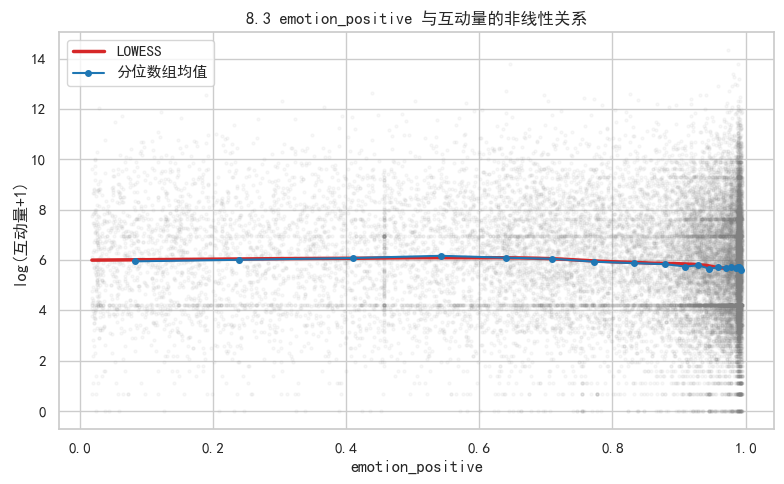

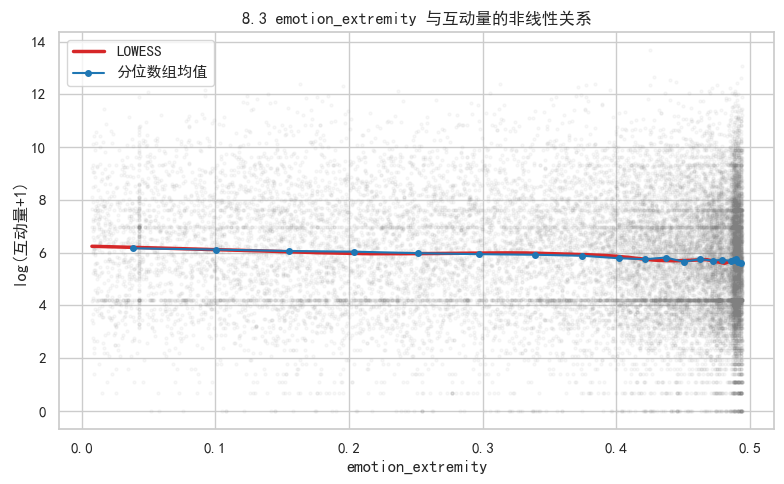

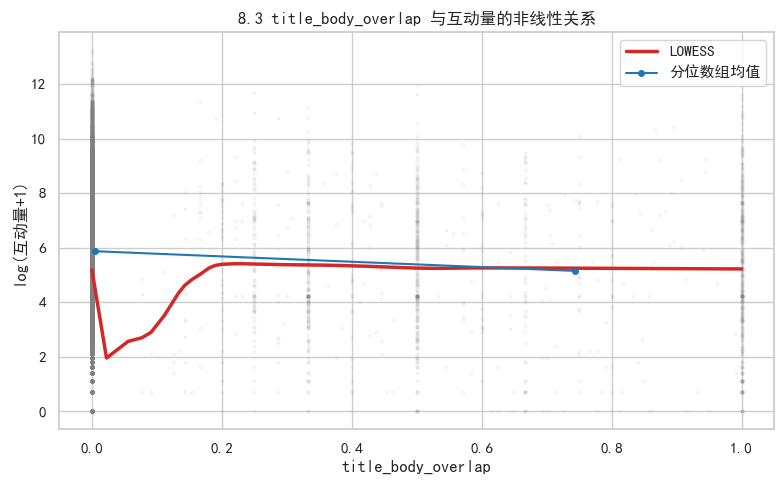

In [8]:
nonlinear_features = ['log_fans', 'content_len', 'tag_count', 'emotion_positive', 'emotion_extremity', 'title_body_overlap']

def nonlinear_plot(data, x, bins=20, sample_n=20000):
    z = data[[x, 'engagement_log']].replace([np.inf, -np.inf], np.nan).dropna()
    z = z[z[x].between(z[x].quantile(.005), z[x].quantile(.995))]
    sample = z.sample(min(sample_n, len(z)), random_state=RANDOM_STATE).sort_values(x)
    smooth = lowess(sample['engagement_log'], sample[x], frac=.25, it=1, return_sorted=True)
    try:
        z['bin'] = pd.qcut(z[x], bins, duplicates='drop')
        grouped = z.groupby('bin', observed=True).agg(x_mean=(x,'mean'), y_mean=('engagement_log','mean'), n=('engagement_log','size')).reset_index(drop=True)
    except ValueError:
        grouped = pd.DataFrame(columns=['x_mean','y_mean','n'])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(sample[x], sample['engagement_log'], s=5, alpha=.05, color='gray', rasterized=True)
    ax.plot(smooth[:,0], smooth[:,1], color='#D62728', lw=2.5, label='LOWESS')
    if len(grouped):
        ax.plot(grouped.x_mean, grouped.y_mean, 'o-', color='#1F77B4', ms=4, label='分位数组均值')
    ax.set_xlabel(x); ax.set_ylabel('log(互动量+1)'); ax.set_title(f'8.3 {x} 与互动量的非线性关系')
    ax.legend(); plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f'8_3_lowess_{x}.png', dpi=180)
    plt.show()
    grouped.to_csv(OUTPUT_DIR / f'8_3_bins_{x}.csv', index=False, encoding='utf-8-sig')
    return grouped

bin_results = {x: nonlinear_plot(df, x) for x in nonlinear_features}

In [9]:
def strength(v):
    a = abs(v)
    return '很弱' if a < .10 else ('弱' if a < .30 else ('中等' if a < .50 else '较强'))

top = target_corr.dropna(subset=['spearman_rho']).head(8).copy()
print('与 log 互动量 Spearman 相关性绝对值最高的特征：')
for _, r in top.iterrows():
    direction = '正' if r.spearman_rho > 0 else '负'
    print(f"- {r.feature}: ρ={r.spearman_rho:.3f}（{strength(r.spearman_rho)}{direction}相关，FDR p={r.spearman_p_fdr:.3g}）")

print('\n文件已输出到：', OUTPUT_DIR.resolve())
print('\n注意：以上结果是探索性相关分析，不能表述为某特征“导致”互动量变化。')

与 log 互动量 Spearman 相关性绝对值最高的特征：
- log_fans: ρ=0.469（中等正相关，FDR p=0）
- body_len: ρ=-0.116（弱负相关，FDR p=0）
- content_len: ρ=-0.115（弱负相关，FDR p=0）
- has_location: ρ=-0.111（弱负相关，FDR p=0）
- emotion_extremity: ρ=-0.070（很弱负相关，FDR p=8.53e-199）
- title_body_overlap: ρ=-0.068（很弱负相关，FDR p=3.81e-183）
- emotion_positive: ρ=-0.063（很弱负相关，FDR p=1.29e-159）
- tag_count: ρ=-0.044（很弱负相关，FDR p=4.7e-77）

文件已输出到： C:\Users\fire\xhs\chapter8_outputs

注意：以上结果是探索性相关分析，不能表述为某特征“导致”互动量变化。
